Outliers-diff technique to identify outliers

3-Sigma Technique(Standard Deviation)
based on principle of normal distribution

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import statistics 
import pandas as pd

In [29]:

df = pd.read_csv("raw_sales2.csv")
type(df)


pandas.core.frame.DataFrame

In [6]:
df.head(5)

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [11]:
#Function to detect outlier on 1D datasets

def find_anomalies(data):
    #define a list to accumlate anomalies
    anomalies=[]
    #set upper limit and lower limit to 3 standard deviation
    random_data_std=statistics.stdev(data)
    random_data_mean=statistics.mean(data)
    #3-standard deviation

    anomaly_cut_off=random_data_std*3 #3sigma
    lower_limit=random_data_mean-anomaly_cut_off #mean-3sigma
    upper_limit=random_data_mean+anomaly_cut_off #mean+3sigma
    #generate outliers
    for outlier in data:
        if outlier>upper_limit or outlier<lower_limit:
            anomalies.append(outlier)
    return anomalies

In [12]:
df.price

0        525000
1        290000
2        328000
3        380000
4        310000
          ...  
29575    500000
29576    560000
29577    464950
29578    589000
29579    775000
Name: price, Length: 29580, dtype: int64

In [13]:
list_1=find_anomalies(df['price'])

In [14]:
len(list_1)

461

In [15]:
len(df)

29580

In [16]:
#461/29580*100=1.55.. beyond +-3sigma for normal distribution it should be 0.3%

In [17]:
df.price.skew()

4.312009366902366

In [18]:
#4.312 positive skew

<Axes: xlabel='price', ylabel='Density'>

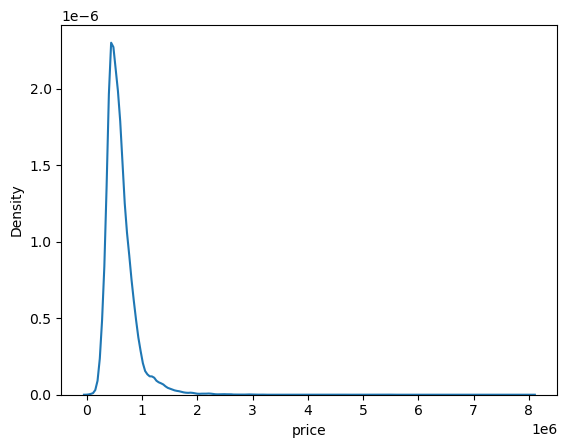

In [20]:
import seaborn as sns
sns.kdeplot(df.price)

In [34]:
df['price_transformed']=np.log(df.price)

In [35]:
df.price_transformed.skew()

0.4731646269984763

In [36]:
list_2=find_anomalies(df.price_transformed)

In [37]:
len(list_2)

266

In [38]:
#266/29580=0.89 percentage better as it come closer to 0.3 percentage

<Axes: xlabel='price_transformed', ylabel='Density'>

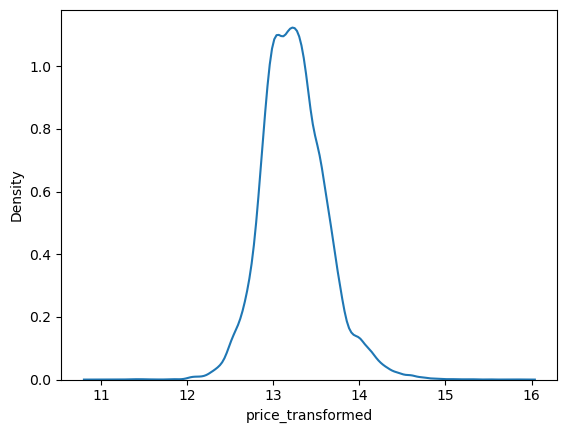

In [39]:
sns.kdeplot(df.price_transformed)

In [40]:
df['price_transformed_double']=np.log(df.price_transformed)

In [41]:
list_3=find_anomalies(df.price_transformed_double)

In [42]:
len(list_3)

251

In [43]:
len(df)

29580

In [44]:
#251/29580=0.8 per
#anything below 40,or above 80 are considered as outliers

Boxplots

<Axes: >

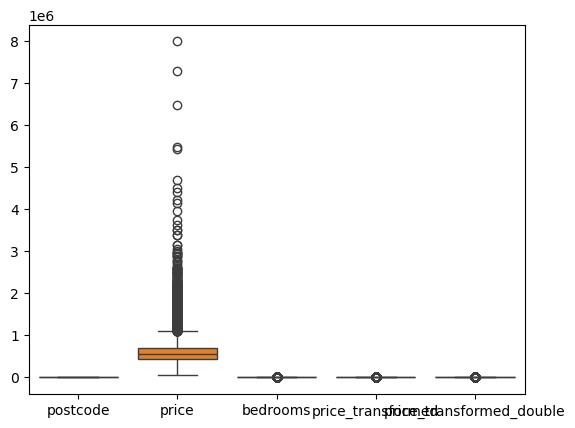

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df)

In [50]:
#The above code displays the plot below
#it considers everything above 75 or below ~-35 to be an outlier.The results are very close to method1 above

In [52]:
df

,datesold,postcode,price,propertyType,bedrooms,price_transformed,price_transformed_double
0,2007-02-07 00:00:00,2607,525000,house,4,13.171154,2.578029
1,2007-02-27 00:00:00,2906,290000,house,3,12.577636,2.531920
2,2007-03-07 00:00:00,2905,328000,house,3,12.700769,2.541663
3,2007-03-09 00:00:00,2905,380000,house,4,12.847927,2.553182
4,2007-03-21 00:00:00,2906,310000,house,3,12.644328,2.537209
...,...,...,...,...,...,...,...
29575,2019-07-25 00:00:00,2900,500000,unit,3,13.122363,2.574318
29576,2019-07-25 00:00:00,2612,560000,unit,2,13.235692,2.582917
29577,2019-07-26 00:00:00,2912,464950,unit,2,13.049685,2.568764
29578,2019-07-26 00:00:00,2601,589000,unit,2,13.286181,2.586725


In [53]:
df.describe()

,postcode,price,bedrooms,price_transformed,price_transformed_double
count,29580.000000,2.958000e+04,29580.000000,29580.000000,29580.000000
mean,2730.249730,6.097363e+05,3.250169,13.244695,2.583199
std,146.717292,2.817079e+05,0.951275,0.375214,0.028183
min,2600.000000,5.650000e+04,0.000000,10.941996,2.392608
25%,2607.000000,4.400000e+05,3.000000,12.994530,2.564529
50%,2615.000000,5.500000e+05,3.000000,13.217674,2.581555
75%,2905.000000,7.050000e+05,4.000000,13.465953,2.600165
max,2914.000000,8.000000e+06,5.000000,15.894952,2.766002


Inter Quartile Range
IQR=Q3-Q1